Sketch some automation snippets that given the info extracted during the model training can optimize spme quantities (e.g. offered rate) and produce som relevant KPI, e.g. accepted rate, expected $ of loans, ...
Based on a simple model using price (or diff to competitor) and quantity

In [13]:
import pandas as pd
import numpy as np
import pymc as pm
from sklearn.model_selection import train_test_split
import arviz as az
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [14]:
#load data 
df = pd.read_excel("data/data.xlsx")
df["DeltaCompetition"] = df["Rate"] - df["Competition rate"]
#Start with only one Tier
df = df[df["Tier"]==2]
mean = df[["Rate", "DeltaCompetition", "Amount"]].mean()
std = df[["Rate", "DeltaCompetition", "Amount"]].std()
df_normalized = df[["Rate", "DeltaCompetition", "Amount"]].apply(lambda x: (x-x.mean())/x.std(), axis=0)
print(f"{df['Outcome'].mean()*100:.2f} % of the loans in the data set have been accepted")
#Use the offered rate as price
prices_train, prices_test, accepted_train, accepted_test, amount_train, amount_test, cost_train, cost_test = train_test_split(df_normalized["Rate"].values, df["Outcome"].values,
                                                                                                        df_normalized["Amount"].values, df["Cost of Funds"].values, train_size=0.8,
                                                                                                        shuffle=True, random_state=1)

#Use the delta between the competitor rate and the offered rate as price
#prices_train, prices_test, accepted_train, accepted_test, amount_train, amount_test, cost_train, cost_test = train_test_split(df_normalized["Rate"].values, df["Outcome"].values,
#                                                                                                        df_normalized["Amount"].values, df["Cost of Funds"].values, train_size=0.8,
#                                                                                                        shuffle=True, random_state=1)
df_normalized.head()

20.40 % of the loans in the data set have been accepted


,Rate,DeltaCompetition,Amount
0,-0.230257,-0.228390,0.141202
1,-1.237988,-0.870552,0.914875
7,-2.480855,-2.379633,-0.305163
11,-1.573898,0.092691,0.004671
14,-1.405943,-0.645795,0.082402


In [15]:
#Start considering price as only factor
base_model = pm.Model()

with base_model:
    offered_rates = pm.Data("offered_rate", prices_train)
    requested_amount = pm.Data("Amount", amount_train)
    y = pm.Data("y", accepted_train)

    # Priors for coefficients
    beta_0 = pm.Normal("beta_0", mu=0, sigma=10)
    beta_1 = pm.Normal("beta_1", mu=0, sigma=10)
    beta_2 = pm.Normal("beta_2", mu=0, sigma=10)


    # Linear model
    logit_p = beta_0 + beta_1*offered_rates + beta_2*requested_amount

    # Likelihood
    p = pm.Deterministic('acceptance_p', pm.math.sigmoid(logit_p))
    y_obs = pm.Bernoulli('y_obs', p=p, observed=y)

In [16]:
trace = pm.sample(draws=2000, tune=500, nuts_sampler="blackjax", cores=4, model=base_model)

Running window adaptation


<Axes: >

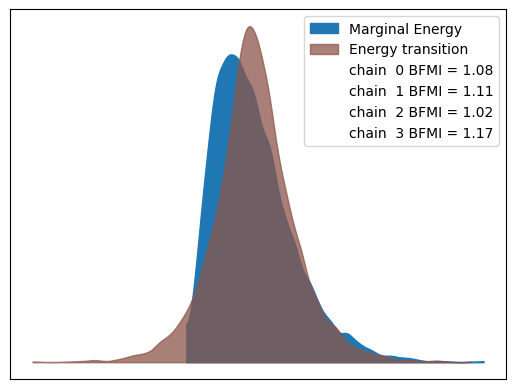

In [17]:
pm.plot_energy(trace)

In [18]:
az.summary(trace, var_names=["beta_0", "beta_1", "beta_2"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,-1.826,0.038,-1.901,-1.757,0.001,0.0,4669.0,4779.0,1.0
beta_1,-0.054,0.030,-0.110,0.000,0.000,0.0,5405.0,5001.0,1.0
beta_2,-1.376,0.042,-1.456,-1.299,0.001,0.0,4753.0,4407.0,1.0


In [19]:
beta_0_mean = trace["posterior"]["beta_0"].mean(dim=["chain", "draw"])
beta_1_mean = trace["posterior"]["beta_1"].mean(dim=["chain", "draw"])
beta_2_mean = trace["posterior"]["beta_2"].mean(dim=["chain", "draw"])

beta_0_dist = np.asarray(trace["posterior"]["beta_0"]).ravel()
beta_1_dist = np.asarray(trace["posterior"]["beta_1"]).ravel()
beta_2_dist = np.asarray(trace["posterior"]["beta_2"]).ravel()



For a fixed set of quantity compute the 50% rate (i.e. the rate that according to the model has a 50% chance of being accepted)
Note that since sigmoid(0) = 0.5 this happens when 0 = b_0 + b_1\*rate +b_2\*amount. So the 50% rate is given by -(b0+b_2\*amount)/b_1

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 1604.11it/s]


([<matplotlib.axis.YTick at 0x7f9c6875d150>,
 [Text(0, 0.0, '0.00'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.1, '0.10'),
  Text(0, 0.15, '0.15'),
  Text(0, 0.2, '0.20')])

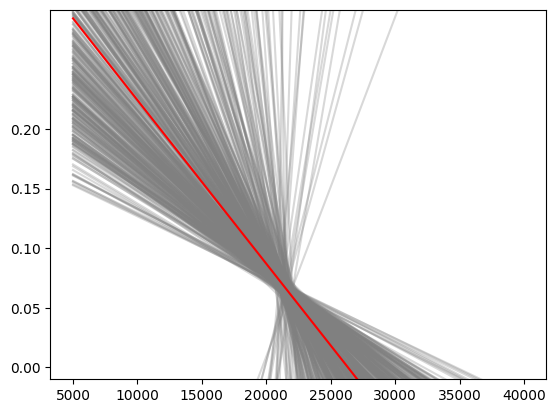

In [20]:

desired_acceptance_rate = 0.2
inv_sig = -np.log((1-desired_acceptance_rate)/desired_acceptance_rate)

amounts = [5000*(i+1) for i in range(8)]
std_amounts = [(x-mean["Amount"])/std["Amount"] for x in amounts] 

std_rates = [(inv_sig-beta_0_mean-beta_2_mean*x)/beta_1_mean for x in std_amounts]
rates = [r*std["Rate"] + mean["Rate"] for r in std_rates]

## 50% is probably optimistic. It is way more than what is observed in the data. Therefore, we get for large loans (where 
# the acceptance probability is very low) that we would need to offer a negative rate to have a 50% probability of accepting
n_sim = 500
for i in tqdm(range(n_sim)):
    beta_0_sample = np.random.choice(beta_0_dist)
    beta_1_sample = np.random.choice(beta_1_dist)
    beta_2_sample = np.random.choice(beta_2_dist)

    std_rates_sample = [(inv_sig-beta_0_sample-beta_2_sample*x)/beta_1_sample for x in std_amounts]
    rates_sample = [r*std["Rate"] + mean["Rate"] for r in std_rates_sample]
    plt.plot(amounts, rates_sample, color="grey", alpha=0.3)

plt.plot(amounts, rates, color="red")
plt.ylim([-0.01, 0.3])
plt.yticks([0,0.05,0.1,0.15, 0.2])

Given the cost of founding c, the offered rate r, the probability of a loan being accepted p, and the requested amount q. The expected income linked to a loan can be expressed as: q*(r-c)*p(r,q) where p(r,q) = sigmoid(b_0+b_1\*r+b_2\*q)

100%|██████████| 500/500 [00:00<00:00, 1354.84it/s]


(-200.0, 500.0)

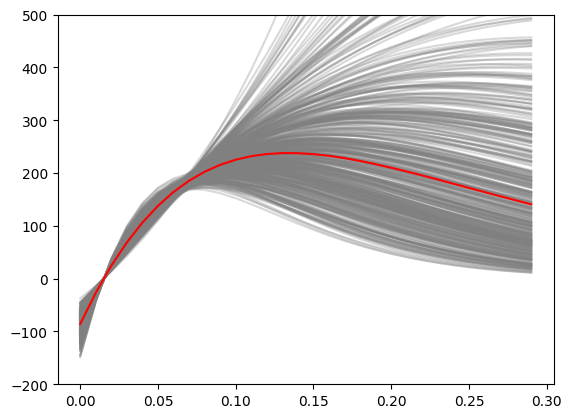

In [21]:
#Example showing how the offered rate is influencing the expected profit on a given loan of 25k with a financing cost of 0.015
q = (25000 - mean["Amount"])/std["Amount"]
c = 0.015
rates = [0.01*i for i in range(30)]
std_rates = [(r-mean["Rate"])/std["Rate"] for r in rates]

for i in tqdm(range(n_sim)):
    beta_0_sample = np.random.choice(beta_0_dist)
    beta_1_sample = np.random.choice(beta_1_dist)
    beta_2_sample = np.random.choice(beta_2_dist)
    expected_profit_sample = [25000*(rates[i]-c)/(1+np.exp(-beta_0_sample-beta_1_sample*std_rates[i]-beta_2_sample*q)) for i in range(len(std_rates))]
    plt.plot(rates, expected_profit_sample, color="gray", alpha=0.3)

expected_profit = [25000*(rates[i]-c)/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[i]-beta_2_mean*q)) for i in range(len(std_rates))]
plt.plot(rates, expected_profit, color="red")
plt.ylim([-200,500])

100%|██████████| 500/500 [00:00<00:00, 974.49it/s] 


(-200.0, 500.0)

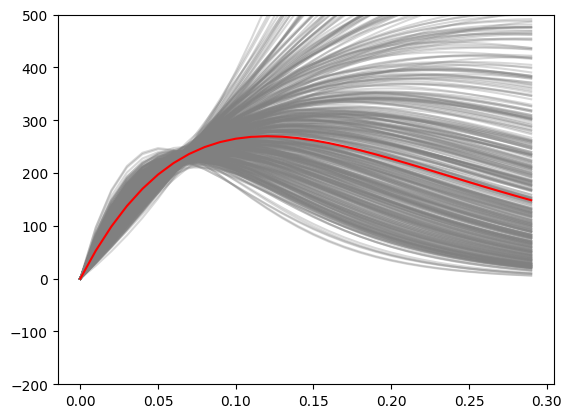

In [ ]:
#Example showing how the offered rate is influencing the expected revenue on a given loan of 25k (with a financing cost of 0.015)
q = (25000 - mean["Amount"])/std["Amount"]
#c = 0.015
rates = [0.01*i for i in range(30)]
std_rates = [(r-mean["Rate"])/std["Rate"] for r in rates]

for i in tqdm(range(n_sim)):
    beta_0_sample = np.random.choice(beta_0_dist)
    beta_1_sample = np.random.choice(beta_1_dist)
    beta_2_sample = np.random.choice(beta_2_dist)
    expected_revenue_sample = [25000*(rates[i])/(1+np.exp(-beta_0_sample-beta_1_sample*std_rates[i]-beta_2_sample*q)) for i in range(len(std_rates))]
    plt.plot(rates, expected_revenue_sample, color="gray", alpha=0.3)

expected_revenue = [25000*(rates[i])/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[i]-beta_2_mean*q)) for i in range(len(std_rates))]
plt.plot(rates, expected_revenue, color="red")
plt.ylim([-200,500])

In [26]:
#Compute benchmark metrics for the test set

test_revenue = sum([(amount_test[i]*std["Amount"]+mean["Amount"])*(prices_test[i]*std["Rate"]+mean["Rate"])*accepted_test[i] for i in range(len(amount_test))]) 
test_profit = sum([(amount_test[i]*std["Amount"]+mean["Amount"])*(prices_test[i]*std["Rate"]+mean["Rate"]-cost_test[i])*accepted_test[i] for i in range(len(amount_test))])

print(f"On a test set of {len(amount_test)} loans")
print("The realized revenue is: ", test_revenue)
print("The realized profit is: ", test_profit)

On a test set of 2092 loans
The realized revenue is:  488507.0623559998
The realized profit is:  379673.31513546966


In [ ]:
#Use the model predictions to set the revenue maximizing price
price_revenue_max= []
acceptance_p_revenue_max = []
revenue_rev_max = []
profit_rev_max = []
#look at all prices between 0 and 30%
rates = [0.01*i for i in range(30)]
std_rates = [(r-mean["Rate"])/std["Rate"] for r in rates]

for i in tqdm(range(len(amount_test))):
    quantity = amount_test[i]*std["Amount"]+mean["Amount"]
    expected_revenue = [quantity*(rates[j])/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[j]-beta_2_mean*amount_test[i])) for j in range(len(std_rates))]
    j_max = np.argmax(expected_revenue)
    price_revenue_max.append(rates[j_max])
    acceptance_p_revenue_max.append(1/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[j_max]-beta_2_mean*amount_test[i])))
    revenue_rev_max.append(quantity*price_revenue_max[i]*acceptance_p_revenue_max[i])
    profit_rev_max.append(quantity*(price_revenue_max[i]-cost_test[i])*acceptance_p_revenue_max[i])

print("Using the Revenue maximizing price proposed by the model we get: ")
print("The expected Revenue is: ", sum(revenue_rev_max).values)
print("The expected Profit is: ", sum(profit_rev_max).values)




100%|██████████| 2092/2092 [01:32<00:00, 22.67it/s]


Using the Revenue maximizing price proposed by the model we get: 
The expected Revenue is:  <xarray.DataArray ()> Size: 8B
array(598839.15561238)
The expected Profit is:  <xarray.DataArray ()> Size: 8B
array(530658.50937983)


In [35]:
#Use the model predictions to set the profit maximizing price
price_profit_max= []
acceptance_p_profit_max = []
revenue_profit_max = []
profit_profit_max = []
#look at all prices between 0 and 30%
rates = [0.01*i for i in range(30)]
std_rates = [(r-mean["Rate"])/std["Rate"] for r in rates]

for i in tqdm(range(len(amount_test))):
    quantity = amount_test[i]*std["Amount"]+mean["Amount"]
    expected_profit = [quantity*(rates[j]-cost_test[i])/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[j]-beta_2_mean*amount_test[i])) for j in range(len(std_rates))]
    j_max = np.argmax(expected_profit)
    price_profit_max.append(rates[j_max])
    acceptance_p_profit_max.append(1/(1+np.exp(-beta_0_mean-beta_1_mean*std_rates[j_max]-beta_2_mean*amount_test[i])))
    revenue_profit_max.append(quantity*price_profit_max[i]*acceptance_p_profit_max[i])
    profit_profit_max.append(quantity*(price_profit_max[i]-cost_test[i])*acceptance_p_profit_max[i])


print("Using the Revenue maximizing price proposed by the model we get: ")
print("The expected Revenue is: ", sum(revenue_profit_max).values)
print("The expected Profit is: ", sum(profit_profit_max).values)

100%|██████████| 2092/2092 [01:35<00:00, 21.95it/s]


Using the Revenue maximizing price proposed by the model we get: 
The expected Revenue is:  595515.8312954004
The expected Profit is:  534153.622100626
